# Основные правила анализа

In [10]:
# Сначала определение, потом число: у каждой метрики есть знаменатель, и он решает всё

# Голое число не значит ничего: ему нужна опора — история, сегмент или сосед для сравнения

# Средние лгут: смотрите распределение и режьте на сегменты

# Сломан не тот шаг, где теряется больше всего, а тот, который изменился

# Сегменты коррелируют: одиночный разрез может показывать чужую тень, разводит подозреваемых перекрёстная таблица

# Совпадение во времени — улика, а не приговор: причинность доказывает только эксперимент

# Прежде чем удивляться разнице, спросите шум: на что он способен при таком размере групп?

# Правила эксперимента назначаются до старта: метрика, MDE, день финиша — и никакого подглядывания

# Вывод, который нельзя пересчитать скриптом из сырых данных, не вывод, а мнение

# Первичный анализ

In [1]:
import pandas as pd

base = "https://python-academy.org/static/product-analytics/dataset"


# parse_dates преобразует столбцы в тип даты для датафрейма
users = pd.read_csv(f"{base}/users.csv", parse_dates=["signup_date"])
products = pd.read_csv(f"{base}/products.csv")
sessions = pd.read_csv(f"{base}/sessions.csv", parse_dates=["started_at"])
orders = pd.read_csv(f"{base}/orders.csv", parse_dates=["created_at"])

print(f"users:    {len(users):>7,}")

print(f"products: {len(products):>7,}")

print(f"sessions: {len(sessions):>7,}")

print(f"orders:   {len(orders):>7,}")

users:      6,000
products:     300
sessions:  68,668
orders:     7,327


In [2]:
# Посмотреть тип данных колонок в датафрейме
users.dtypes

user_id                     object
signup_date         datetime64[ns]
source                      object
country                     object
device_first                object
age_bucket                  object
marketing_opt_in              bool
dtype: object

In [3]:
# Посмотреть историчность данных во всех таблицах
print(f"users:    {users['signup_date'].min().date()} → {users['signup_date'].max().date()}")

print(f"sessions: {sessions['started_at'].min().date()} → {sessions['started_at'].max().date()}")

print(f"orders:   {orders['created_at'].min().date()} → {orders['created_at'].max().date()}")

users:    2025-06-01 → 2026-05-31
sessions: 2025-06-01 → 2026-05-31
orders:   2025-06-01 → 2026-06-01


In [4]:
# Проверка пропусков
print(users.isna().sum())

user_id               0
signup_date           0
source                0
country               0
device_first          0
age_bucket          309
marketing_opt_in      0
dtype: int64


In [5]:
print(sessions.isna().sum())

session_id         0
user_id            0
started_at         0
duration_sec       0
device             0
source             0
country         2078
pages_viewed       0
reached_step       0
dtype: int64


In [6]:
# Уникальные значения в колонке
print(users["source"].unique())

['paid_social' 'organic' 'paid_search' 'referral' 'email']


In [7]:
# Проверка дублей
print(f"дублей user_id:    {users['user_id'].duplicated().sum()}")

print(f"дублей session_id: {sessions['session_id'].duplicated().sum()}")

print(f"дублей order_id:   {orders['order_id'].duplicated().sum()}")

дублей user_id:    0
дублей session_id: 8
дублей order_id:   0


In [8]:
# Описание базовой статистики конкретного столбца

# Среднее в полтора раза больше медианы, а максимум в пять раз выше 75-го перцентиля — 
# это намёк на длинный хвост: небольшая доля крупных заказов сильно тянет среднее вверх.
print(orders["total_rub"].describe())

count      7327.000000
mean      34012.965743
std       34653.869367
min         230.000000
25%        8650.000000
50%       21900.000000
75%       47100.000000
max      243400.000000
Name: total_rub, dtype: float64


# Срезы и фильтры

In [9]:
# Конструкция-аналог where

completed = orders[orders["status"] == "completed"]
print(f"завершённых заказов: {len(completed)} из {len(orders)}")

завершённых заказов: 6986 из 7327


In [10]:
# Применение метода к маске считается автоматически по True условию
# Одна строка вместо двух подсчётов и деления — так доли считают в реальной работе

print(f"доля завершённых: {(orders['status'] == 'completed').mean():.1%}")

print(f"доля мобильных сессий: {(sessions['device'] == 'mobile').mean():.1%}")

доля завершённых: 95.3%
доля мобильных сессий: 57.9%


In [11]:
# Конструкция-аналог where с несколькими условиями
# Кроме & есть | (или) и ~ (не)

march = orders[
    (orders["created_at"] >= "2026-03-01") & (orders["created_at"] < "2026-04-01")
]
print(f"заказов в марте: {len(march)}")

заказов в марте: 1025


In [12]:
# Конструкция-аналог in

cis = users[users["country"].isin(["KZ", "BY", "UA"])]
print(f"пользователей из KZ, BY, UA: {len(cis)}")

пользователей из KZ, BY, UA: 1835


In [13]:
# в query можно через строку вставить много условий
# имена колонок без кавычек, а строковые значения — в одинарных кавычках

big = orders.query("total_rub > 50_000 and status == 'completed'")
print(f"крупных завершённых заказов: {len(big)}")

крупных завершённых заказов: 1639


In [14]:
# loc для фильтрации только нужных столбцов датафрейма

kz = users.loc[users["country"] == "KZ", ["user_id", "signup_date", "source"]]
print(f"пользователей из KZ: {len(kz)}")

print(kz.head())

пользователей из KZ: 921
    user_id signup_date       source
0   u_00001  2026-04-04  paid_social
18  u_00019  2026-04-18  paid_search
25  u_00026  2025-09-17     referral
29  u_00030  2026-03-11      organic
31  u_00032  2026-05-23  paid_social


In [15]:
# Для создания нового отфильтрованного датафрейма стоит создать копию среза

kz = users.loc[users["country"] == "KZ", ["user_id", "signup_date", "source"]].copy()

# Группировки

In [16]:
# Сколько строк в каждой группе

print(users["source"].value_counts())

source
paid_social    2082
organic        1502
paid_search    1243
email           594
referral        579
Name: count, dtype: int64


In [17]:
# С аргументом normalize подсчет доли вместо количества

print((users["source"].value_counts(normalize=True) * 100).round(1))

source
paid_social    34.7
organic        25.0
paid_search    20.7
email           9.9
referral        9.6
Name: proportion, dtype: float64


In [18]:
# groupby среднее total_rub по полю items_count

print(orders.groupby("items_count")["total_rub"].mean().round(0))

items_count
1    16739.0
2    33888.0
3    51248.0
Name: total_rub, dtype: float64


In [19]:
# agg позволяет считать несколько разных агрегаций, как в SQL через запятую

print(orders.groupby("status").agg(
    orders=("order_id", "count"),     # имя_колонки=(откуда, чем считать)
    revenue=("total_rub", "sum"),
    avg_order=("total_rub", "mean"),
).round(0))

           orders    revenue  avg_order
status                                 
cancelled     205    7136750    34813.0
completed    6986  236572460    33864.0
returned      136    5503790    40469.0


In [20]:
# size() считает строки в каждой группе, как value_counts

print(orders.groupby(orders["created_at"].dt.to_period("M")).size())

created_at
2025-06      13
2025-07      45
2025-08      90
2025-09     136
2025-10     230
2025-11     384
2025-12     468
2026-01     576
2026-02     664
2026-03    1025
2026-04    1267
2026-05    2427
2026-06       2
Freq: M, dtype: int64


In [21]:
# loc[source] позволяет вывести только нужную/нужные строки

source = 'organic'
res = (users['source'].value_counts(normalize=True) * 100).round(1).loc[source]
print(res)

25.0


# Объединение таблиц

In [22]:
# merge аналоги join

merged = orders.merge(users[["user_id", "country"]], on="user_id")

# проверка строк и столбцов датафрейма
print(f"после: {merged.shape}")

print(merged[["order_id", "user_id", "total_rub", "status", "country"]].head())

после: (7327, 8)
  order_id  user_id  total_rub     status country
0  o_00001  u_00002      25150  completed      RU
1  o_00002  u_00003      31650  completed      RU
2  o_00003  u_00009      13900  completed      UA
3  o_00004  u_00010        690  completed      RU
4  o_00005  u_00013       2100  completed      US


In [23]:
# Сначала фильтруем ранее сджойненный датафрейм, потом считает группировки

completed = merged[merged["status"] == "completed"]
revenue = completed.groupby("country")["total_rub"].sum().sort_values(ascending=False)
print(revenue)

country
RU    118048670
KZ     36474780
BY     22779310
UA     12280270
US     12220350
DE     10534790
PL      7401090
TR      7242150
AM      5434320
GE      4156730
Name: total_rub, dtype: int64


In [24]:
# Перевод результата в миллионы

print((revenue / 1e6).round(1))

country
RU    118.0
KZ     36.5
BY     22.8
UA     12.3
US     12.2
DE     10.5
PL      7.4
TR      7.2
AM      5.4
GE      4.2
Name: total_rub, dtype: float64


In [25]:
# Аналог left join

left = users.merge(orders[["user_id", "order_id"]], on="user_id", how="left")

# Проверка сколько строк с null в конкретном столбце
print(f"пользователей без заказов: {left['order_id'].isna().sum()}")

пользователей без заказов: 2303


In [26]:
# nunique аналог distinct count

buyers = orders["user_id"].nunique()
print(f"покупателей: {buyers} из {len(users)} ({buyers / len(users):.1%})")

покупателей: 3697 из 6000 (61.6%)


# Работа с датами

In [27]:
print("месяц:", orders["created_at"].dt.month.head(3).tolist())

print("год:", orders["created_at"].dt.year.head(3).tolist())

print("день недели:", orders["created_at"].dt.day_name().head(3).tolist())


print("Период год-месяц:", orders["created_at"].dt.to_period('M').head(3).tolist())

print("Период год:", orders["created_at"].dt.to_period('Y').head(3).tolist())

print("Период день", orders["created_at"].dt.to_period('D').head(3).tolist())


месяц: [12, 5, 11]
год: [2025, 2026, 2025]
день недели: ['Monday', 'Saturday', 'Friday']
Период год-месяц: [Period('2025-12', 'M'), Period('2026-05', 'M'), Period('2025-11', 'M')]
Период год: [Period('2025', 'Y-DEC'), Period('2026', 'Y-DEC'), Period('2025', 'Y-DEC')]
Период день [Period('2025-12-22', 'D'), Period('2026-05-09', 'D'), Period('2025-11-21', 'D')]


In [28]:
# resample заполнит нулями столбец, если по этому значению нет данных
# шаг сетки задаётся строкой: "D" дни, "W" недели, "ME" месяцы.

daily = orders.set_index("created_at").resample("D").size()

# внутри loc можно указывать диапазон как в списке
print(daily.loc["2025-11-24":"2025-12-03"])

created_at
2025-11-24     9
2025-11-25    10
2025-11-26    15
2025-11-27    17
2025-11-28    25
2025-11-29    26
2025-11-30    25
2025-12-01    17
2025-12-02    10
2025-12-03    13
Freq: D, dtype: int64


In [29]:
# выручка по месяцам в миллионах

completed = orders[orders["status"] == "completed"]
monthly = completed.set_index("created_at")["total_rub"].resample("ME").sum()
print((monthly / 1e6).round(1))

created_at
2025-06-30     0.3
2025-07-31     1.1
2025-08-31     3.4
2025-09-30     4.3
2025-10-31     8.9
2025-11-30    12.5
2025-12-31    15.5
2026-01-31    18.0
2026-02-28    20.7
2026-03-31    31.2
2026-04-30    40.6
2026-05-31    80.0
2026-06-30     0.0
Freq: ME, Name: total_rub, dtype: float64


In [30]:
# Сколько заказов приходится на сто сессий каждый месяц?

completed = orders[orders["status"] == "completed"]
monthly = completed.set_index("created_at")["total_rub"].resample("ME").sum()
print((monthly / 1e6).round(1))

created_at
2025-06-30     0.3
2025-07-31     1.1
2025-08-31     3.4
2025-09-30     4.3
2025-10-31     8.9
2025-11-30    12.5
2025-12-31    15.5
2026-01-31    18.0
2026-02-28    20.7
2026-03-31    31.2
2026-04-30    40.6
2026-05-31    80.0
2026-06-30     0.0
Freq: ME, Name: total_rub, dtype: float64


# Основные метрики

In [31]:
# Активные пользователи за май (просто те, кто посещал сервис в мае)
may_visit = sessions[
    (sessions["started_at"] >= "2026-05-01") & (sessions["started_at"] < "2026-06-01")
]["user_id"].nunique()

# Активные пользователи за май (те, кто что-то в мае купил)
may_buy = orders[
    (orders["created_at"] >= "2026-05-01") & (orders["created_at"] < "2026-06-01")
]["user_id"].nunique()

print(f"по визитам: {may_visit}, по покупкам: {may_buy}")

по визитам: 4822, по покупкам: 1610


In [32]:
# DAU (daily active users) — число уникальных пользователей за день.
 
# Ключевое слово «уникальных»: пользователь с тремя сессиями за день это один активный пользователь, 
# поэтому nunique, а не подсчёт сессий.

dau = sessions.set_index("started_at").resample("D")["user_id"].nunique()
print(dau.loc["2026-05-25":"2026-05-31"])

started_at
2026-05-25    771
2026-05-26    732
2026-05-27    739
2026-05-28    762
2026-05-29    798
2026-05-30    830
2026-05-31    827
Freq: D, Name: user_id, dtype: int64


In [33]:
# Тоже самое с другой гранулярностью

s = sessions.set_index("started_at")
print(s.resample("W")["user_id"].nunique().tail(4))

print(s.resample("ME")["user_id"].nunique().tail(4))

started_at
2026-05-10    2308
2026-05-17    2433
2026-05-24    2596
2026-05-31    2794
Freq: W-SUN, Name: user_id, dtype: int64
started_at
2026-02-28    2556
2026-03-31    3294
2026-04-30    3970
2026-05-31    4822
Freq: ME, Name: user_id, dtype: int64


In [34]:
# Sticky_factor (липкость)

# Сами по себе DAU и MAU растут у любого продукта с растущей базой — мы это проходили. 
# Их отношение интереснее: средний DAU месяца, делённый на MAU, показывает, 
# какую долю дней месяца типичный пользователь проводит с продуктом.

dau = sessions.set_index("started_at").resample("D")["user_id"].nunique()
mau = s.resample("ME")["user_id"].nunique()
sticky_factor = (dau.resample("ME").mean() / mau * 100).round(1)
print(sticky_factor)

started_at
2025-06-30     4.7
2025-07-31     5.5
2025-08-31     5.4
2025-09-30     6.1
2025-10-31     6.0
2025-11-30     6.5
2025-12-31     6.6
2026-01-31     7.2
2026-02-28     7.6
2026-03-31     8.4
2026-04-30     9.9
2026-05-31    12.9
Freq: ME, Name: user_id, dtype: float64


In [35]:
# Конверсия сессии в покупку

print(f"{(sessions['reached_step'] == 'purchase').mean():.1%}")

10.7%


In [36]:
# Пример расчет разных сегментов воронки конверсий

reached_cart = sessions["reached_step"].isin(["cart", "checkout", "purchase"])
reached_checkout = sessions["reached_step"].isin(["checkout", "purchase"])
reached_purchase = sessions["reached_step"] == "purchase"

print(f"корзина → оформление: {reached_checkout.sum() / reached_cart.sum():.1%}")

print(f"оформление → покупка: {reached_purchase.sum() / reached_checkout.sum():.1%}")

корзина → оформление: 63.0%
оформление → покупка: 79.5%


In [37]:
first_order = orders.groupby("user_id")["created_at"].min().rename("first_order")
u = users.merge(first_order, on="user_id", how="left")
u["days_to_purchase"] = (u["first_order"] - u["signup_date"]).dt.days

print(f"за всё время: {u['first_order'].notna().mean():.1%}")

print(f"за первые 14 дней: {(u['days_to_purchase'] <= 14).mean():.1%}")

# Половина покупателей делает первый заказ позже 36-го дня
print(f"медиана дней до первой покупки: {u['days_to_purchase'].median():.0f}")

за всё время: 61.6%
за первые 14 дней: 18.5%
медиана дней до первой покупки: 36


# Средний чек

In [38]:
# AOV это выручка, делённая на число заказов, то есть обычное среднее по суммам.

completed = orders[orders["status"] == "completed"]

print(f"средний чек: {completed['total_rub'].mean():.0f}")

print(f"медианный чек: {completed['total_rub'].median():.0f}")

средний чек: 33864
медианный чек: 21800


In [39]:
# quantile отвечает на вопрос «дешевле какой суммы лежит такая-то доля заказов»


print(completed["total_rub"].quantile([0.25, 0.5, 0.75, 0.9, 0.99]).round(0))

0.25      8478.0
0.50     21800.0
0.75     46812.0
0.90     89800.0
0.99    145100.0
Name: total_rub, dtype: float64


In [40]:
t = completed["total_rub"]
threshold = t.quantile(0.9)
share = t[t >= threshold].sum() / t.sum()
print(f"топ-10% заказов (дороже {threshold:.0f}) дают {share:.1%} выручки")

топ-10% заказов (дороже 89800) дают 33.6% выручки


# ARPU/ARPPU

In [41]:
may = completed[
    (completed["created_at"] >= "2026-05-01") & (completed["created_at"] < "2026-06-01")
]

may_rev = may["total_rub"].sum()

mau = sessions[
    (sessions["started_at"] >= "2026-05-01") & (sessions["started_at"] < "2026-06-01")
]["user_id"].nunique()

print(f"ARPU:  {may_rev / mau:.0f}")

print(f"ARPPU: {may_rev / may['user_id'].nunique():.0f}")

ARPU:  16582
ARPPU: 51521


In [42]:


def arpu_parts(ym):
    s = sessions[sessions["started_at"].dt.to_period("M").astype(str) == ym]
    
    completed = orders[orders["status"] == "completed"]
    c = completed[completed["created_at"].dt.to_period("M").astype(str) == ym]
    
    mau = s["user_id"].nunique()
    print(f"{ym}: визитов на активного {len(s) / mau:.2f} "
          f"× конверсия {len(c) / len(s):.1%} × чек {c['total_rub'].mean():.0f} "
          f"= {c['total_rub'].sum() / mau:.0f}")

arpu_parts("2026-03")

arpu_parts("2026-05")

2026-03: визитов на активного 2.76 × конверсия 10.7% × чек 32045 = 9466
2026-05: визитов на активного 5.03 × конверсия 9.5% × чек 34585 = 16582


In [43]:
# LTV (lifetime value) это выручка, которую человек приносит за всё время с продуктом.
# Самый простой расчет

# Честную LTV считают по группам пользователей одного возраста

completed = orders[orders["status"] == "completed"]
print(f"на зарегистрированного: {completed['total_rub'].sum() / len(users):.0f}")

print(f"на покупателя: {completed['total_rub'].sum() / completed['user_id'].nunique():.0f}")

на зарегистрированного: 39429
на покупателя: 65678


# Когорты

In [44]:
# Когорта это группа пользователей, объединённых моментом одного и того же стартового события.
# Ключевой трюк когортного анализа: время отсчитывается не по календарю, а от старта когорты. 
# Не «что было в апреле», а «что было на 14-й день жизни пользователя». Так группы разных возрастов становятся сравнимыми


s = sessions.merge(users[["user_id", "signup_date"]], on="user_id")
s["age_days"] = (s["started_at"] - s["signup_date"]).dt.days # вычисление возраста аккаунта на момент сессии


# Оставляются только те сессии, которые произошли в первые 14 дней (включительно) с момента регистрации пользователя. 
# .copy() используется, чтобы избежать предупреждений pandas при дальнейших изменениях этого датафрейма.
early = s[s["age_days"] <= 14].copy()
# Создается столбец cohort, который содержит месяц регистрации пользователя
early["cohort"] = early["signup_date"].dt.to_period("M")

# Здесь мы берем исходную таблицу users, группируем её по месяцу регистрации и считаем общее количество уникальных пользователей, 
# зарегистрировавшихся в каждом месяце. Результат — это Series, где индекс — это месяц, а значение — число пользователей.
cohort_size = users.groupby(users["signup_date"].dt.to_period("M"))["user_id"].count()

# early.groupby("cohort")["session_id"].count() считает общее количество ранних сессий в каждой месячной когорте.
# Это число делится на cohort_size (общее число пользователей в этой когорте).
print((early.groupby("cohort")["session_id"].count() / cohort_size).round(2))

cohort
2025-06    0.48
2025-07    0.63
2025-08    0.57
2025-09    0.71
2025-10    0.78
2025-11    0.90
2025-12    0.98
2026-01    1.29
2026-02    1.68
2026-03    2.29
2026-04    3.94
2026-05    9.27
Freq: M, dtype: float64


In [45]:
# Какая доля визитов кончается покупкой, в тех же самых когортах

# Когорты, чьи первые недели пришлись на апрель и позже, 
# конвертируют ранний визит примерно на пятую часть хуже.

# Активность когорт растёт (это объясняет «здоровые» средние второй фазы), а отдача с визита у новых когорт упала (это трещина из тикета)
early["is_purchase"] = early["reached_step"] == "purchase"
print((early.groupby("cohort")["is_purchase"].mean() * 100).round(1))

cohort
2025-06    10.7
2025-07    12.9
2025-08     8.4
2025-09     9.1
2025-10     9.0
2025-11    15.7
2025-12    11.1
2026-01    12.3
2026-02    12.7
2026-03    10.4
2026-04    10.3
2026-05     9.7
Freq: M, Name: is_purchase, dtype: float64


In [46]:
# Три правила когортного анализа

# Фиксируй окно. Сравнивать когорты можно только по одинаковому отрезку жизни: первые 14 дней против первых 14 дней, а не «всё, что успело накопиться».
# Помечай несозревшие когорты. У 310 из 703 майских пользователей 14-й день жизни ещё не наступил: их окно обрезано справа, и значение когорты занижено. Такие точки либо исключают, либо явно помечают.
# Подписывай размер когорты. Маленькие когорты шумят: летние 8.4% и 15.7% это не события, а статистическая рябь на паре сотен человек.

# Retention-матрица

In [47]:
# Retention-матрица отвечает на вопрос, который задаёт себе каждый продукт: возвращаются ли к нам люди. 
# Строки в ней это когорты, столбцы это месяцы жизни когорты, в ячейке доля когорты, дожившая до этого месяца.

In [48]:
# Этот код реализует классический когортный анализ удержания (Retention Analysis). 
# Он строит знаменитую "треугольную" таблицу (Retention Triangle), которая показывает, какой процент пользователей, 
# зарегистрировавшихся в определенном месяце, вернулся в приложение в последующие месяцы (0-й месяц, 1-й месяц, 2-й месяц и так далее


users["cohort"] = users["signup_date"].dt.to_period("M") # Теперь мы знаем, к какому месячному "призыву" (когорте) относится каждый пользователь.
s = sessions.merge(users[["user_id", "cohort"]], on="user_id") # Теперь каждая строка-сессия "знает", в каком месяце зарегистрировался её автор.
s["month"] = s["started_at"].dt.to_period("M") # Мы создаем столбец month, который показывает месяц, когда произошла конкретная сессия.

# Это ключевой шаг. Мы вычитаем месяц регистрации (cohort) из месяца сессии (month).
# Если пользователь зарегистрировался в Январе (2023-01) и сделал сессию в Январе (2023-01), разница равна 0.
# Если сессия была в Феврале (2023-02), разница равна 1.
# Если в Марте (2023-03), разница равна 2.
# Метод .apply(lambda d: d.n) извлекает из полученного объекта разницы периодов (PeriodOffset) чистое целое число. 
# Столбец m теперь показывает: "Сколько полных месяцев прошло с момента регистрации".
s["m"] = (s["month"] - s["cohort"]).apply(lambda d: d.n)

# groupby(["cohort", "m"]): мы группируем данные по месяцу регистрации и по номеру месяца с момента регистрации.
# ["user_id"].nunique(): мы считаем количество уникальных пользователей (это критически важно! В предыдущем вашем коде был count(), который считал сессии. Здесь nunique() считает именно людей, что правильно для Retention).
# .unstack(): эта функция берет внутренний уровень группировки (m) и превращает его в столбцы.
active = s.groupby(["cohort", "m"])["user_id"].nunique().unstack()

# Мы считаем, сколько всего пользователей зарегистрировалось в каждом месяце. 
# Это Series, где индекс — это месяц (cohort), а значение — общее число людей.
cohort_size = users.groupby("cohort")["user_id"].count()

# Мы делим таблицу active на Series cohort_size.
# Параметр axis=0 здесь критически важен. Он говорит pandas: 
# "Бери каждую строку таблицы active и дели все её значения на число из cohort_size, которое соответствует индексу (названию когорты) этой строки".
# * 100: превращает долю в проценты.
retention = (active.div(cohort_size, axis=0) * 100).round(1)
print(retention.iloc[:, :7])

m            0     1     2     3     4     5     6
cohort                                            
2025-06   31.9  53.5  50.0  50.0  60.2  57.5  57.9
2025-07   38.9  59.8  62.3  65.4  60.4  62.6  62.6
2025-08   33.5  58.4  61.0  63.2  63.5  52.1  54.9
2025-09   41.5  63.7  66.1  66.8  67.3  63.5  65.9
2025-10   44.3  68.2  69.7  65.6  67.0  67.6  69.5
2025-11   44.3  75.4  72.9  69.7  73.6  72.9  74.3
2025-12   51.0  77.1  72.0  77.6  74.4  75.0   NaN
2026-01   58.6  78.6  80.3  80.9  79.3   NaN   NaN
2026-02   63.8  87.9  85.7  85.2   NaN   NaN   NaN
2026-03   72.1  90.4  93.0   NaN   NaN   NaN   NaN
2026-04   81.1  96.2   NaN   NaN   NaN   NaN   NaN
2026-05  100.0   NaN   NaN   NaN   NaN   NaN   NaN


In [49]:
# Как читать

# Строка → «Жизненный путь одного призыва»
# Что это: Берёшь одну строку (одну когорту) и читаешь её слева направо. Это как смотреть документальный фильм про конкретный «призыв» пользователей — от их первого дня до сегодняшнего.
# Что ищем: Как менялась активность этой когорты со временем? Где она «осела» (вышла на плато)? Есть ли провалы или всплески?
# Зачем это нужно: Понять, как ведёт себя конкретный призыв. Если все когорты ведут себя одинаково (например, все выходят на плато 60%) — это здоровый паттерн, продукт работает стабильно.

# Столбец → «Сравнение призывов в одном возрасте»
# Что это: Берёшь один столбец (один возраст, например, m=1) и читаешь его сверху вниз. Это как сделать «фотографию» всех когорт в один и тот же момент их жизни — например, через месяц после регистрации.
# Что ищем: Становится ли продукт лучше со временем? Каждый новый призыв «живучее» предыдущего или хуже?
# Зачем это нужно: Понять, улучшается ли продукт. Если столбцы растут сверху вниз — продукт становится лучше, пользователи приходят более «качественные» или онбординг работает эффективнее. 
# Если столбцы падают — что-то сломалось.

# Диагональ → «Один календарный месяц во всех когортах»
# Что это: Идёшь по диагонали сверху-вниз. Это как взять «фотографию» всего продукта в один конкретный календарный месяц (например, в сентябре 2025) и посмотреть, 
# как в этот месяц вели себя все когорты — каждая в своём возрасте.
# Зачем это нужно: Найти внешние события, которые повлияли на всех пользователей одновременно. 
# Если провал идёт по диагонали — значит, проблема была в продукте в конкретный месяц (баг, изменение политики, сезонность). 
# Если провал идёт по строке — значит, проблема была в конкретном призыве (плохой маркетинг, некачественные пользователи).




In [50]:
# По строкам: Когорты не «умирают», а набирают активность со временем. Это нетипично для классического ретеншена (обычно значения падают). 
# Возможно, у тебя продукт с отложенным эффектом (обучение, подписка) или пользователи возвращаются после перерыва.
# По столбцам: Каждый новый призыв значительно активнее предыдущего. Это отличный знак — продукт улучшается.
# По диагоналям: Нет явных провалов, которые шли бы по диагоналям. Значит, не было катастрофических событий, которые бы одновременно уронили все когорты.

# LTV-когорты

In [51]:
# LTV-кривая когорты отвечает на вопрос «сколько в среднем принёс один пользователь когорты к месяцу жизни m».

users["cohort"] = users["signup_date"].dt.to_period("M")
completed = orders[orders["status"] == "completed"]

c = completed.merge(users[["user_id", "cohort"]], on="user_id")
c["month"] = c["created_at"].dt.to_period("M")
c = c[c["month"] <= "2026-05"] # Фильтр c["month"] <= "2026-05" отрезает пограничный июньский хвост из двух заказов, чтобы правый край матрицы не засоряли копеечные ячейки.
c["m"] = (c["month"] - c["cohort"]).apply(lambda d: d.n)

cohort_size = users.groupby("cohort")["user_id"].count()
rev = c.groupby(["cohort", "m"])["total_rub"].sum().unstack()
ltv = rev.cumsum(axis=1).div(cohort_size, axis=0).round(0)
print(ltv.iloc[:, :7])

m              0        1        2        3        4        5        6
cohort                                                                
2025-06   1345.0   3744.0   8945.0  10762.0  16159.0  19153.0  25573.0
2025-07   1541.0   6397.0  10345.0  15960.0  21590.0  25563.0  28775.0
2025-08   1386.0   4380.0   9775.0  14497.0  19150.0  22210.0  25765.0
2025-09   3203.0   8922.0  13334.0  19591.0  25831.0  30508.0  36052.0
2025-10   2510.0   9460.0  15575.0  21934.0  26504.0  31007.0  37341.0
2025-11   5089.0  11028.0  17775.0  23808.0  29861.0  35682.0  42590.0
2025-12   3323.0  10584.0  16993.0  25409.0  29714.0  37243.0      NaN
2026-01   4156.0  11556.0  19009.0  26536.0  35084.0      NaN      NaN
2026-02   6595.0  19234.0  29526.0  42712.0      NaN      NaN      NaN
2026-03   6776.0  22851.0  37585.0      NaN      NaN      NaN      NaN
2026-04  11441.0  40267.0      NaN      NaN      NaN      NaN      NaN
2026-05  33699.0      NaN      NaN      NaN      NaN      NaN      NaN


In [52]:
# Мы фильтруем таблицу заказов, оставляя только те, у которых статус "completed". 
# Отмененные или ожидающие оплаты заказы не приносят реальной выручки, поэтому для расчета LTV они не нужны.
completed = orders[orders["status"] == "completed"]

# К успешным заказам мы присоединяем из таблицы users три важных столбца:
# user_id (ключ для связи)
# cohort (месяц регистрации пользователя)
# source (источник трафика, откуда пришел пользователь, например, "organic", "facebook_ads", "email").
src = completed.merge(users[["user_id", "cohort", "source"]], on="user_id")
src["m"] = (src["created_at"].dt.to_period("M") - src["cohort"]).apply(lambda d: d.n)

# Мы берем только тех пользователей, которые зарегистрировались в феврале 2026 года или раньше.
# Зачем? Чтобы посчитать выручку за 3 месяца (m <= 2), у когорты должно быть минимум 3 месяца "жизни" в прошлом
mature = users[users["cohort"] <= "2026-02"]


# Из таблицы с заказами (src) мы оставляем только те строки, которые удовлетворяют двум условиям:
# Заказ был сделан в первые 3 месяца жизни пользователя (m <= 2, то есть месяцы 0, 1 и 2).
# Пользователь принадлежит к "зрелой" когорте (чтобы данные были сопоставимы).
early_rev = src[(src["m"] <= 2) & (src["cohort"] <= "2026-02")]

print(early_rev.groupby("source")["total_rub"].sum())
print(mature.groupby("source")["user_id"].count())
# На самом деле, здесь делится не датафрейм на датафрейм, а Series (одномерный столбец с индексом) на Series.
# Вся магия происходит благодаря механизму, который в pandas называется Index Alignment (выравнивание по индексу). 
# Pandas не делит "первую строку на первую строку" наугад. 
# Он смотрит на названия индексов (в данном случае — на названия источников трафика) и делит значения только там, где названия совпадают.

# Если индексы не соответствуют, Pandas не выдаст ошибку. 
# Он увидит, что для "email" нет пары в левой части, и автоматически подставит значение NaN (Not a Number)
ltv3 = (
    early_rev.groupby("source")["total_rub"].sum()
    / mature.groupby("source")["user_id"].count()
).round(0).sort_values(ascending=False)
print(ltv3)

source
email           8873420
organic        15947690
paid_search    14148110
paid_social    18696130
referral        7748880
Name: total_rub, dtype: int64
source
email           406
organic         963
paid_search     784
paid_social    1363
referral        382
Name: user_id, dtype: int64
source
email          21856.0
referral       20285.0
paid_search    18046.0
organic        16560.0
paid_social    13717.0
dtype: float64


# Воронка

In [53]:
# Можно пробежаться по срезу с каким-то выражением

steps = ["home", "product", "cart", "checkout", "purchase"]
counts = pd.Series(
    [sessions["reached_step"].isin(steps[i:]).sum() for i in range(len(steps))],
    index=steps,
)
print(counts)

home        68668
product     48753
cart        14631
checkout     9215
purchase     7327
dtype: int64


In [54]:
# Один способ подсчет конверсии
# «От всех» показывает сквозную дорогу: до покупки доезжает 10.7%

of_all = (counts / counts.iloc[0] * 100).round(1)
print(of_all)

home        100.0
product      71.0
cart         21.3
checkout     13.4
purchase     10.7
dtype: float64


In [55]:
# Второй способ подсчета конверсии между соседними статусами
# shift(1) сдвигает серию на одну позицию вниз: каждый шаг делится на предыдущий. У первого шага предшественника нет

of_prev = (counts / counts.shift(1) * 100).round(1)
print(of_prev)

home         NaN
product     71.0
cart        30.0
checkout    63.0
purchase    79.5
dtype: float64


# Сегментирование воронки

In [56]:
# Разрез устройства

steps = ["home", "product", "cart", "checkout", "purchase"]

# Из гроупбай собирается словарь, а из него датафрейм
funnel = pd.DataFrame({
    dev: [g["reached_step"].isin(steps[i:]).sum() for i in range(len(steps))]
    for dev, g in sessions.groupby("device")
}, index=steps)


print((funnel / funnel.shift(1) * 100).round(1))

          desktop  mobile  tablet
home          NaN     NaN     NaN
product      70.7    71.1    71.5
cart         31.4    29.4    29.1
checkout     69.8    57.8    69.9
purchase     80.2    79.0    79.5


In [57]:
# Разрез источники
#  конверсию из Корзины (Cart) в Оформление заказа (Checkout)

# paid_social тоже проваливается, 56.9% против ровных 64-65 у остальных
# потенциальный подозреваемый

df = sessions.copy()
df["cart"] = df["reached_step"].isin(["cart", "checkout", "purchase"])
df["chk"] = df["reached_step"].isin(["checkout", "purchase"])

res = df.groupby("source").agg(cart=("cart", "sum"), chk=("chk", "sum"))
res["conv"] = (res["chk"] / res["cart"] * 100).round(1)
print(res)

             cart   chk  conv
source                       
direct       2576  1675  65.0
email        1622  1047  64.5
organic      4228  2730  64.6
paid_search  2074  1322  63.7
paid_social  2879  1639  56.9
referral     1252   802  64.1


In [58]:
df["is_mobile"] = df["device"] == "mobile"
print((df.groupby("source")["is_mobile"].mean() * 100).round(0))

source
direct         58.0
email          61.0
organic        50.0
paid_search    54.0
paid_social    70.0
referral       53.0
Name: is_mobile, dtype: float64


In [59]:
# Двумерный разрез

# Читаем по строкам: внутри каждого источника мобильные хуже десктопа на 8-14 пунктов. 
# Мобильный провал не принадлежит каналу, он живёт во всех каналах сразу

df = sessions.copy()
df["cart"] = df["reached_step"].isin(["cart", "checkout", "purchase"])
df["chk"] = df["reached_step"].isin(["checkout", "purchase"])

res2 = df.groupby(["source", "device"]).agg(cart=("cart", "sum"), chk=("chk", "sum"))
res2["conv"] = (res2["chk"] / res2["cart"] * 100).round(1)
print(res2["conv"].unstack())


device       desktop  mobile  tablet
source                              
direct          72.7    59.1    74.3
email           70.9    60.0    73.1
organic         70.6    57.9    72.3
paid_search     68.6    60.0    66.5
paid_social     62.6    54.3    63.9
referral        71.5    57.9    66.1


# Воронка во времени

In [60]:
# Мобильная колонка все четыре месяца перед апрелем держится в коридоре 66-71: 66.1, 66.2, 71.1, 68.3. 
# А в апреле 47.8, в мае 50.0. Обвал на двадцать пунктов за один месяц, и никакого восстановления.

# А на колонки соседей это никак не повлияло

df = sessions.copy()
df["ym"] = df["started_at"].dt.to_period("M")
df["cart"] = df["reached_step"].isin(["cart", "checkout", "purchase"])
df["chk"] = df["reached_step"].isin(["checkout", "purchase"])

g = df.groupby(["ym", "device"]).agg(cart=("cart", "sum"), chk=("chk", "sum"))
print((g["chk"] / g["cart"] * 100).round(1).unstack())

device   desktop  mobile  tablet
ym                              
2025-06     46.2    71.4    50.0
2025-07     75.0    61.4    77.8
2025-08     66.7    63.5    73.9
2025-09     71.7    59.6    64.9
2025-10     65.1    66.7    66.7
2025-11     71.5    73.9    70.3
2025-12     70.5    66.1    79.3
2026-01     70.8    66.2    70.4
2026-02     67.9    71.1    76.5
2026-03     68.7    68.3    68.1
2026-04     70.5    47.8    66.0
2026-05     70.2    50.0    70.0


In [61]:
# Проверка двух каналов за разные период через цикл

for dev in ["mobile", "desktop"]:
    d = df[df["device"] == dev]
    pre = d[d["ym"] < "2026-04"]
    post = d[d["ym"] >= "2026-04"]
    print(f"{dev}: до {pre['chk'].sum() / pre['cart'].sum() * 100:.1f}, "
          f"после {post['chk'].sum() / post['cart'].sum() * 100:.1f}")

mobile: до 68.1, после 49.2
desktop: до 69.2, после 70.3


# Гипотеза

In [62]:
# Рабочая гипотеза отвечает на четыре вопроса: что случилось (причина), с чем (метрика), у кого (сегмент) и насколько (величина).

# Например:
# Редизайн мобильного чекаута, выпущенный 1 апреля 2026, снизил конверсию шага корзина → 
# оформление на мобильных устройствах с ~68% до ~49%, то есть на 19 процентных пунктов.

In [63]:
# Примерный подсчет упущенной выручки за интересующий период

# Логика оценки: корзины, которые не дошли бы до оформления из-за поломки (потерянные 18.9 п.п.), 
# домноженные на обычную проходимость следующего шага и средний чек. Около 11.6 млн ₽ в месяц при майской выручке в 80 млн

df = sessions.copy()
completed = orders[orders["status"] == "completed"]

df["ym"] = df["started_at"].dt.to_period("M")
mob_post = df[(df["device"] == "mobile") & (df["ym"] >= "2026-04")]
carts = mob_post["reached_step"].isin(["cart", "checkout", "purchase"]).sum()

lost_step = 0.681 - 0.492        # потерянная конверсия шага (урок о времени)
chk_to_purchase = 0.790          # оформление -> покупка на мобильных (урок о сегментах)
aov = completed[completed["created_at"] >= "2026-04-01"]["total_rub"].mean()

lost_rub = carts * lost_step * chk_to_purchase * aov
print(f"мобильных корзин за апрель-май: {carts}")

print(f"недополученная выручка: {lost_rub / 1e6:.1f} млн ₽, или {lost_rub / 2 / 1e6:.1f} млн ₽ в месяц")


мобильных корзин за апрель-май: 4548
недополученная выручка: 23.2 млн ₽, или 11.6 млн ₽ в месяц


# Шум

In [24]:
# Берем все сессии
# Оставляем только мобильные сессии мая 2026
# Из них оставляем только тех, кто дошел до корзины (или дальше)
# Считаем, сколько из них дошло до чекаута (конверсия cart → checkout)
# Выводим результат всей группы до деления на половины

df = sessions.copy()
may = df[(df["device"] == "mobile") & (df["started_at"].dt.to_period("M") == "2026-05")]
carts = may[may["reached_step"].isin(["cart", "checkout", "purchase"])].copy()
carts["chk"] = carts["reached_step"].isin(["checkout", "purchase"])
print(f"корзин: {len(carts)}, конверсия шага: {carts['chk'].mean() * 100:.1f}%")

корзин: 2997, конверсия шага: 50.0%


In [25]:
# Проверку такого рода называют A/A-тестом: эксперимент, 
# где обе группы получают одинаковый опыт, и потому всё, что между ними различается, заведомо шум


import numpy as np


# default_rng() — это современный способ создавать генератор в numpy.
# 42 — это "зерно" (seed). Оно гарантирует, что каждый раз при запуске кода случайные числа будут одинаковыми. Это нужно для воспроизводимости результатов.
rng = np.random.default_rng(42)

# rng.permutation(1000) < 500 — сравнивает каждое число из перемешанного массива с числом 500
group_a = rng.permutation(len(carts)) < len(carts) // 2

# расчет двух групп, ~ это отрицание маски, то есть считаем False значения
conv_a = carts[group_a]["chk"].mean() * 100
conv_b = carts[~group_a]["chk"].mean() * 100

print(f"группа A: {conv_a:.1f}%, группа B: {conv_b:.1f}%, разница: {conv_a - conv_b:.1f} п.п.")


# Вывод: Даже если мы ничего не меняем, случайное деление данных всегда дает небольшую разницу между группами. Это статистический шум (случайная вариация).
# Теперь, когда мы будем проводить настоящий A/B-тест (где группе B покажем новую форму), мы сможем сравнить:
# Если разница между A и B больше, чем 1.4 п.п. (например, 7.4 п.п.), то это, скорее всего, реальный эффект новой формы.
# Если разница меньше или около 1.4 п.п., то это может быть просто случайность, и новой форме радоваться рано.

группа A: 50.7%, группа B: 49.3%, разница: 1.4 п.п.


In [26]:
diffs = []
for _ in range(1000):
    g = rng.permutation(len(carts)) < len(carts) // 2
    diffs.append(carts[g]["chk"].mean() * 100 - carts[~g]["chk"].mean() * 100)

diffs = pd.Series(diffs)

# В 95% вселенных разница уложилась в коридор от минус 3.6 до плюс 3.6 пункта.
print(f"размах шума: от {diffs.quantile(0.025):.1f} до {diffs.quantile(0.975):.1f} п.п.")

# Проверка сколько раз встретилась разница больше 5 п.п.
print(f"разниц от 5 п.п.: {(diffs.abs() >= 5).sum()} из 1000")

# Проверка сколько раз встретилась разница больше 19 п.п.
print(f"разниц от 19 п.п.: {(diffs.abs() >= 19).sum()} из 1000")

размах шума: от -3.6 до 3.6 п.п.
разниц от 5 п.п.: 6 из 1000
разниц от 19 п.п.: 0 из 1000


# P-value

In [14]:
tab = sessions[sessions["device"] == "tablet"]
carts = tab[tab["reached_step"].isin(["cart", "checkout", "purchase"])].copy()
carts["chk"] = carts["reached_step"].isin(["checkout", "purchase"])
carts["post"] = carts["started_at"] >= "2026-04-01"

print(f'Сессий после апреля: {len(carts[~carts["post"]]["chk"])}')
print(f'Сессий до апреля: {len(carts[carts["post"]]["chk"])}')

pre = carts[~carts["post"]]["chk"].mean() * 100
post = carts[carts["post"]]["chk"].mean() * 100
print(f"корзин: {len(carts)}, до апреля: {pre:.1f}%, с апреля: {post:.1f}%")



print(f"наблюдаемая разница: {post - pre:.1f} п.п.")

Сессий после апреля: 672
Сессий до апреля: 810
корзин: 1482, до апреля: 71.6%, с апреля: 68.5%
наблюдаемая разница: -3.1 п.п.


In [6]:
# Нулевая гипотеза

# Сформулируем позицию скептика: «апрель планшетам ничего не сделал, а минус 3.1 нарисовала случайность»

In [20]:
import numpy as np

rng = np.random.default_rng(42)

# Запоминаем реальную наблюдаемую разницу
obs = post - pre

# Мы создаем 1000 "фальшивых вселенных", где ничего не менялось (никакого эффекта от апреля не было), 
# и смотрим, какая разница могла бы возникнуть просто из-за случайности.
diffs = []
for _ in range(1000):
    # Получает булев массив, где примерно 672 значения True и 810 значений False
    fake = rng.permutation(len(carts)) < carts["post"].sum()
    # Мы считаем разницу конверсий между этими случайными группами
    diffs.append(carts[fake]["chk"].mean() * 100 - carts[~fake]["chk"].mean() * 100)

diffs = pd.Series(diffs)

# abs(obs) — модуль наблюдаемой разницы (например, abs(7.3) = 7.3)
# diffs.abs() — модули всех 1000 случайных разниц (потому что нам важно, насколько разница экстремальная, независимо от знака)
# (diffs.abs() >= abs(obs)) — булев массив: True, если случайная разница по модулю больше или равна наблюдаемой
# .sum() — считаем, сколько раз это произошло
extreme = (diffs.abs() >= abs(obs)).sum()
print(f"вселенных с разницей от {abs(obs):.1f} п.п.: {extreme} из 1000")

print(f"p-value: {extreme / 1000:.2f}")

# Как интерпретировать результат?
# p-value — это вероятность получить такую же или большую разницу просто из-за случайности, если бы на самом деле ничего не менялось.
# Обычно используют порог p < 0.05 (5%). Если p-value меньше 0.05, разница считается значимой.

# Если p-value>0.05
# Разница НЕ статистически значима
# такая разница (или даже больше) могла возникнуть просто случайно в 21% случаев
# Это слишком часто, чтобы утверждать, что апрель реально что-то изменил
# Нельзя сделать вывод, что изменение в апреле сработало

# Если p-value<0.05
# Разница статистически значима
# Это очень редко (меньше 5%)
# Можно с уверенностью (100 - p-value)% утверждать, что апрель реально повлиял на конверсию


вселенных с разницей от 3.1 п.п.: 214 из 1000
p-value: 0.21


In [23]:
# Сделаем тоже самое для мобильных

def permutation_p(device):
    d = sessions[sessions["device"] == device]
    carts = d[d["reached_step"].isin(["cart", "checkout", "purchase"])].copy()
    carts["chk"] = carts["reached_step"].isin(["checkout", "purchase"])
    post = carts["started_at"] >= "2026-04-01"
    obs = carts[post]["chk"].mean() * 100 - carts[~post]["chk"].mean() * 100

    rng = np.random.default_rng(42)
    extreme = 0
    for _ in range(1000):
        fake = rng.permutation(len(carts)) < post.sum()
        if abs(carts[fake]["chk"].mean() * 100 - carts[~fake]["chk"].mean() * 100) >= abs(obs):
            extreme += 1
    return obs, extreme

obs, extreme = permutation_p("mobile")
print(f"мобильные: разница {obs:.1f} п.п., экстремальных вселенных {extreme} из 1000")

# ноль не значит p-value равен нулю: тысяча симуляций не умеет видеть события реже одной тысячной, 
# поэтому честная запись — p < 0.001. Так выглядит результат, на который шум не способен.

# P-value 0.21 не доказывает, что эффекта нет. Может, апрель и задел планшеты на пункт-другой, просто полутора тысяч корзин мало, чтобы отличить такой эффект от шума. 
# Отсутствие улик и доказательство невиновности — разные вещи.

# P-value это не вероятность, что нулевая гипотеза верна. 
# Он отвечает на вопрос «как часто скучный мир рисует такую разницу», а не «какова вероятность, что мир скучный». Перепутать легко, а смыслы разные.

# И порог 0.05, который вы встретите везде: разницу, у которой p-value ниже порога, называют статистически значимой. 
# Сам порог — не закон природы, а договорённость, как проходной балл. Удобная, общепринятая и немного произвольная: между p = 0.049 и p = 0.051 нет пропасти.

мобильные: разница -18.9 п.п., экстремальных вселенных 0 из 1000


# Дизайн эксперимента

In [35]:
# Сначала выясним, сколько данных у нас вообще есть. 
# Эксперимент делит мобильные корзины пополам, значит, скорость накопления известна из обычной жизни магазина

may = sessions[(sessions["device"] == "mobile") & (sessions["started_at"].dt.to_period("M") == "2026-05")]
carts = may[may["reached_step"].isin(["cart", "checkout", "purchase"])]

print(f"мобильных корзин в мае: {len(carts)}, в неделю: {len(carts) // 4}, на группу: {len(carts) // 8}")

мобильных корзин в мае: 2997, в неделю: 749, на группу: 374


In [37]:
import numpy as np

rng = np.random.default_rng(42)
n = 375
p0 = 0.492

# Биномиальное распределение моделирует ситуацию: "Есть n независимых испытаний, каждое succeeds с вероятностью p. Сколько будет успехов?"
# В нашем контексте:
# n = 375 — количество корзин в одной группе (недельный объем, как посчитано в len(carts) // 8)
# p0 = 0.492 — вероятность того, что одна корзина пройдет дальше (реальная конверсия)
# 2000 — количество симуляций (2000 воображаемых недельных экспериментов)
# rng.binomial(n, p0, 2000) генерирует 2000 чисел, где каждое число — это "сколько корзин из 375 пройдут дальше, если конверсия равна 49.2%"
a = rng.binomial(n, p0, 2000) / n
b = rng.binomial(n, p0, 2000) / n

# Мы создаем 2000 воображаемых A/A-тестов, где:
# Группа A имеет конверсию, случайно сгенерированную вокруг 49.2%
# Группа B имеет конверсию, случайно сгенерированную вокруг тех же 49.2%
# Ничего не меняется, обе группы живут в одинаковых условиях
# Затем мы считаем разницу между A и B в каждом из 2000 экспериментов
noise = pd.Series(abs(a - b) * 100)

# И находим 95-й перцентиль этого распределения разниц
# Это критическое значение для будущих A/B-тестов
cutoff = noise.quantile(0.95)
print(f"граница шума для групп по {n}: {cutoff:.1f} п.п.")


# Практическое применение:
# Если в будущем ты проведешь реальный A/B-тест (где группе B покажешь новую форму) и увидишь разницу:
# Меньше 6.9 п.п. → скорее всего, это случайность (шум), нельзя делать выводы
# Больше 6.9 п.п. → разница статистически значима (на уровне 95% доверия), новая форма реально работает лучше/хуже

граница шума для групп по 375: 6.9 п.п.


In [43]:
# Статистическая мощность теста
# Если мы проведем A/B-тест, где новая форма реально улучшает конверсию на 5 процентных пунктов, то в каком проценте случаев мы это обнаружим?

# Каждое число в массиве a — это "какая конверсия получилась бы в группе A в одной воображаемой неделе, если новая форма работает"
a = rng.binomial(n, p0 + 0.05, 2000) / n
b = rng.binomial(n, p0, 2000) / n

# если разница больше или равна 6.9 п.п. (мы "поймали" эффект), False — если меньше (эффект утонул в шуме).
caught = (abs(a - b) * 100 >= cutoff).mean() * 100
print(f"эффект +5 п.п. пойман в {caught:.0f}% миров")

# Стандарт мощности >= 80%
# В данном случае я упущу около 70% реальных улучшений

# Что делать, если мощность меньше стандарта
# Вариант 1: Увеличить размер групп
# Самый очевидный способ. Если сейчас n = 100, попробуй n = 400 или n = 1000.
# Как это влияет:
# Больше данных → меньше шума
# Граница шума (cutoff) уменьшается
# Мощность растет

# Вариант 2: Проводить тест дольше
# Вместо недельного теста делай двухнедельный или месячный.
# Пример:
# Было: 1 неделя × 100 корзин = 100 корзин в группе
# Стало: 4 недели × 100 корзин = 400 корзин в группе

# Вариант 3: Искать большие эффекты
# Если не можешь увеличить выборку, фокусируйся на гипотезах, которые могут дать +10 п.п. или больше, а не +2 п.п.
# Логика:
# Большие эффекты легче обнаружить даже с маленькой выборкой
# Маленькие эффекты требуют огромных выборок

# Вариант 4: Снизить порог значимости
# Вместо cutoff на уровне 95% перцентиля использовать 90% перцентиль.
# Но это опасно:
# Вырастет вероятность ложных срабатываний (false positives)
# Ты начнешь внедрять изменения, которые на самом деле не работают

эффект +5 п.п. пойман в 30% миров


In [50]:
# Построение таблицы мощности для разных размеров групп и эффектов

# Если я планирую A/B-тест, какой размер групп мне нужен, чтобы обнаружить эффект определенного размера
# Он строит таблицу, где по строкам — размеры групп, по столбцам — размеры эффектов, а в ячейках — мощность (вероятность обнаружить эффект).
# Эффект, который мы заранее хотим ловить называется минимальным детектируемым эффектом, по-английски MDE

def power(n, effect_pp, p0=0.492, sims=2000):
    a0 = rng.binomial(n, p0, sims) / n # 2000 случайных конверсий для группы A с базовой вероятностью p0
    b0 = rng.binomial(n, p0, sims) / n # 2000 случайных конверсий для группы B с той же базовой вероятностью p0
    cutoff = pd.Series(abs(a0 - b0) * 100).quantile(0.95) #  95-й перцентиль этого распределения (граница шума)

    # Теперь мы проводим 2000 воображаемых A/B-тестов, где группа A реально лучше:
    a1 = rng.binomial(n, p0 + effect_pp / 100, sims) / n # 2000 случайных конверсий для группы A с улучшенной вероятностью p0 + effect_pp/100
    b1 = rng.binomial(n, p0, sims) / n # 2000 случайных конверсий для группы B с базовой вероятностью p0
    return (abs(a1 - b1) * 100 >= cutoff).mean() * 100 # проверяем, в скольких случаях разница ≥ cutoff и считаем долют таких случаев (мощность в процентах)

ns = [375, 750, 1500, 3000] # это размеры групп, которые мы хотим протестировать

# Это генератор списка, который создает двумерный массив:
# Внешний цикл: для каждого размера группы n из ns
# Внутренний цикл: для каждого эффекта e из [2, 5, 19]
# Вызывает power(n, e) и сохраняет результат
table = pd.DataFrame(
    [[power(n, e) for e in [2, 5, 19]] for n in ns],
    index=ns, columns=["+2 п.п.", "+5 п.п.", "+19 п.п."],
)
table.index.name = "корзин в группе" # задает название для индекса (строк)
print(table.round(0))

# Как читать таблицу

# Строки: сколько корзин в каждой группе (A и B)
# Строки — размер групп: неделя, две, четыре, восемь.
# Столбцы: насколько новая версия лучше старой (в процентных пунктах)
# Значения: в каком проценте случаев ты обнаружишь этот эффект (мощность)

# +19 п.п., полное восстановление из нашей гипотезы: ловится с гарантией даже за неделю
# +5 п.п., частичное восстановление: четыре недели дают 76%, на грани планки; для уверенности нужно восемь
# +2 п.п.: безнадёжно. Даже восемь недель ловят его реже, чем в половине миров

# У этой безнадёжности есть закон: ошибка измерения убывает как корень из размера группы, поэтому ловить вдвое меньший эффект — собирать вчетверо больше данных. 
# Для +2 п.п. с мощностью 80% нужно порядка десяти тысяч корзин на группу, полгода трафика

                 +2 п.п.  +5 п.п.  +19 п.п.
корзин в группе                            
375                  8.0     28.0     100.0
750                 12.0     49.0     100.0
1500                21.0     81.0     100.0
3000                35.0     97.0     100.0


# Анализ A/B теста

In [52]:
# Читаем таблицу после четырех недель A/B теста

# Одна строка — один участник: вариант формы (A значит старая, B новая), самый дальний шаг и принесённые деньги. 
# Три тысячи корзин за четыре недели, как и обещал бюджет трафика.

ab = pd.read_csv(f"{base}/ab_test_checkout.csv", parse_dates=["assigned_at"])
print(f"строк: {len(ab)}")
строк: 3000
print(ab.head(3))

строк: 3000
     user_id variant         assigned_at reached_step  revenue_rub
0  abu_00001       B 2026-06-13 03:53:03     purchase       104375
1  abu_00002       A 2026-06-11 18:01:14     checkout            0
2  abu_00003       A 2026-06-12 22:19:10     purchase         9464


In [54]:
# Проверяем распределение внутри групп

print(ab["variant"].value_counts())
# Не ровно

variant
A    1517
B    1483
Name: count, dtype: int64


In [56]:
# Разыграем две тысячи таких делений

import numpy as np

rng = np.random.default_rng(42)
sizes = rng.binomial(len(ab), 0.5, 2000)
lo, hi = pd.Series(sizes).quantile([0.025, 0.975])
print(f"честное деление 3000 пополам: группа A от {lo:.0f} до {hi:.0f}")

# 1517 сидит глубоко внутри коридора, деление честное. 
# Эта проверка называется проверкой на перекос выборки (sample ratio mismatch, SRM), и пропускать её нельзя: 
# если размеры групп выпадают из коридора, рандомизация где-то сломана, 
# и читать метрики такого эксперимента бессмысленно — любая разница может быть следствием поломки деления, а не формы.

честное деление 3000 пополам: группа A от 1447 до 1556


In [59]:
# Веса в порядке, поэтому проверяем интересовавший нас этап конверсии

ab["chk"] = ab["reached_step"].isin(["checkout", "purchase"])
res = ab.groupby("variant").agg(carts=("chk", "size"), conv=("chk", "mean"))
res["conv"] = (res["conv"] * 100).round(1)
print(res)

# Старая форма: 69.5%. Новая: 48.6%. 
# Гипотеза предсказывала «с ~68% до ~49%» — попадание практически в точку, в обе цифры сразу. 
# Осталось формально спросить шум

         carts  conv
variant             
A         1517  69.5
B         1483  48.6


In [63]:
# Две случайные группы, одно время, единственное различие — форма. 
# То, что не могли доказать ни разрезы, ни совпадение дат, доказал эксперимент: 
# мобильный чекаут ломает именно редизайн. Дело закрыто.

obs = ab[ab["variant"] == "A"]["chk"].mean() * 100 - ab[ab["variant"] == "B"]["chk"].mean() * 100
n_a = (ab["variant"] == "A").sum()

extreme = 0
for _ in range(1000):
    fake = rng.permutation(len(ab)) < n_a
    if abs(ab[fake]["chk"].mean() * 100 - ab[~fake]["chk"].mean() * 100) >= abs(obs):
        extreme += 1
print(f"разница {obs:.1f} п.п., экстремальных вселенных {extreme} из 1000")

print(f'p-value: {extreme/1000}')
# p-value=0(0.001)

разница 21.0 п.п., экстремальных вселенных 0 из 1000
p-value: 0.0


In [64]:
# Дальше проверка вторичных метрик
# Cледующий шаг, оформление → покупка

chk = ab[ab["chk"]].copy()
chk["pur"] = chk["reached_step"] == "purchase"
print((chk.groupby("variant")["pur"].mean() * 100).round(1))

# У сломанной формы шаг покупки выше: 80.4 против 76.8
# Случайными были группы на входе, у корзины. Но до шага оформления в группе B добрались не случайные люди, 
# а те, кого не остановила сломанная форма — самые упорные и мотивированные. 
# Сравнивая группы после сломанного шага, мы сравниваем уже не формы, а разных людей. 
# Рандомизация живёт только в той точке, где делили; ниже по воронке её защита кончается.



variant
A    76.8
B    80.4
Name: pur, dtype: float64


In [66]:
# Выручка на участника, метрика, в которой сходится вся воронка:

print(ab.groupby("variant")["revenue_rub"].mean().round(0))

obs = ab[ab["variant"] == "A"]["revenue_rub"].mean() - ab[ab["variant"] == "B"]["revenue_rub"].mean()

extreme = 0
for _ in range(1000):
    fake = rng.permutation(len(ab)) < n_a
    if abs(ab[fake]["revenue_rub"].mean() - ab[~fake]["revenue_rub"].mean()) >= abs(obs):
        extreme += 1
print(f"разница {obs:.0f} ₽ на корзину, экстремальных вселенных {extreme} из 1000")

# Старая форма приносит на 4821 ₽ с корзины больше, и шум такую разницу не рисует никогда.

variant
A    18060.0
B    13238.0
Name: revenue_rub, dtype: float64
разница 4821 ₽ на корзину, экстремальных вселенных 0 из 1000


# Проблема подглядывания

In [2]:
import numpy as np

# ng.binomial(week_n, p0, (sims, 4)) — генерирует матрицу размером (2000, 4):
# 2000 строк — это 2000 симуляций A/A-тестов
# 4 столбца — это 4 недели
# Каждое значение — количество "успехов" (корзин, прошедших дальше) за одну неделю из 375 корзин
# .cumsum(axis=1) — накопительная сумма по строкам (по неделям):
# Столбец 0: данные за 1-ю неделю
# Столбец 1: данные за 1-ю + 2-ю неделю (сумма)
# Столбец 2: данные за 1-ю + 2-ю + 3-ю неделю (сумма)
# Столбец 3: данные за все 4 недели (сумма)

rng = np.random.default_rng(42)
p0 = 0.492
sims = 2000

week_n = 375
a = rng.binomial(week_n, p0, (sims, 4)).cumsum(axis=1)
b = rng.binomial(week_n, p0, (sims, 4)).cumsum(axis=1)
n_cum = week_n * np.arange(1, 5) # массив сколько корзин накопилось к каждой неделе
diffs = np.abs(a - b) / n_cum * 100 #  матрица diffs размером (2000, 4), где каждое значение — это разница в процентах между A и B на соответствующей неделе.

cutoffs = np.quantile(diffs, 0.95, axis=0) # Для каждого столбца (недели) считаем 95-й перцентиль — это граница шума.
print("границы шума по неделям:", cutoffs.round(1))

# Если ты каждую неделю проверяешь, не превысила ли разница границу шума, и останавливаешь тест при первом же срабатывании, то вероятность ложного срабатывания растет.
# Если бы ты смотрел на результат только в конце (на 4-й неделе), вероятность ложного срабатывания была бы 5% (потому что cutoff — это 95-й перцентиль).

# Проблема: Если ты "подглядываешь" каждую неделю и останавливаешь тест при первом срабатывании, ты можешь остановиться слишком рано, 
# когда разница еще большая (7.5 п.п.), но это может быть случайность, а не реальный эффект.

# Как правильно бороться с "подглядыванием"
# Метод 1: Фиксированный размер выборки
# Заранее: "Тест будет длиться 4 недели, и я посмотрю на результат только в конце". Тогда вероятность ложного срабатывания = 5%.

# Метод 2: Коррекция на множественные проверки
# Если ты хочешь смотреть каждую неделю, нужно ужесточить границы шума (например, использовать поправку Бонферрони или последовательные методы, like O'Brien-Fleming).

# Метод 3: Последовательный анализ
# Использовать специальные методы (like group sequential designs), которые учитывают, что ты смотришь на результат несколько раз.

границы шума по неделям: [7.5 5.1 4.3 3.7]


In [3]:
day_n = 54 # day_n = 54 — это 54 корзины в день (375 корзин в неделю ÷ 7 дней ≈ 54)

# rng.binomial(day_n, p0, (sims, 28)) — генерирует матрицу размером (2000, 28):
# 2000 строк — 2000 симуляций A/A-теста
# 28 столбцов — 28 дней (4 недели)
# Каждое значение — количество "успехов" за один день из 54 корзин
a = rng.binomial(day_n, p0, (sims, 28)).cumsum(axis=1)
b = rng.binomial(day_n, p0, (sims, 28)).cumsum(axis=1)
n_cum = day_n * np.arange(1, 29)
diffs = np.abs(a - b) / n_cum * 100

cutoffs = np.quantile(diffs, 0.95, axis=0)

# Это побитовое сравнение матрицы diffs (2000 × 28) с массивом cutoffs (28 значений).
# Pandas/numpy автоматически транслирует (broadcast) массив cutoffs на каждую строку матрицы diffs.
# Результат: булева матрица размером (2000, 28), где:
# True — разница в этот день превысила границу шума
# False — разница не превысила границу
print(f"при ежедневном подглядывании: {(diffs >= cutoffs).any(axis=1).mean() * 100:.1f}% пустышек")

при ежедневном подглядывании: 28.6% пустышек


# Резюмирование

In [4]:
import pandas as pd

base = "https://python-academy.org/static/product-analytics/dataset"

sessions = pd.read_csv(f"{base}/sessions.csv", parse_dates=["started_at"])
ab = pd.read_csv(f"{base}/ab_test_checkout.csv")

mob = sessions[sessions["device"] == "mobile"]
carts = mob[mob["reached_step"].isin(["cart", "checkout", "purchase"])].copy()
carts["chk"] = carts["reached_step"].isin(["checkout", "purchase"])
post = carts["started_at"] >= "2026-04-01"
print(f"шаг корзина -> оформление: {carts[~post]['chk'].mean() * 100:.1f}% до релиза, {carts[post]['chk'].mean() * 100:.1f}% после")

ab["chk"] = ab["reached_step"].isin(["checkout", "purchase"])
exp = ab.groupby("variant")["chk"].mean() * 100
print(f"эксперимент: старая форма {exp['A']:.1f}%, новая {exp['B']:.1f}%")

rev = ab.groupby("variant")["revenue_rub"].mean()
print(f"деньги: +{rev['A'] - rev['B']:.0f} ₽ с корзины у старой формы, ~{(rev['A'] - rev['B']) * 3000 / 1e6:.0f} млн ₽ в месяц")

шаг корзина -> оформление: 68.1% до релиза, 49.2% после
эксперимент: старая форма 69.5%, новая 48.6%
деньги: +4821 ₽ с корзины у старой формы, ~14 млн ₽ в месяц


In [5]:
# Вывод

# Что случилось. Релиз редизайна мобильного чекаута 1 апреля уронил конверсию шага корзина → оформление на мобильных устройствах с 68% до 49%. 
# Магазин недополучает около 14 млн ₽ в месяц, это 18% майской выручки.

# Откуда уверенность. Поломка видна в трёх независимых разрезах данных (шаг воронки, устройство, дата) и доказана экспериментом на 3 000 пользователей: 
# возврат старой формы поднял конверсию шага до 69.5% против 48.6% у новой и принёс +4 800 ₽ с корзины. Случайностью такая разница не объясняется (p < 0.001).

# Рекомендация. Вернуть старую форму всем мобильным пользователям на этой неделе. Доработанный редизайн выпускать только через новый A/B-тест.

# Риски и границы. Мы не знаем, какой именно элемент новой формы мешает покупателям: нужен отдельный разбор с записями сессий. 
# У редизайна могут быть неизмеренные плюсы — меньше ошибок в адресах, задел под будущие функции. Их стоит взвесить до окончательного отказа от макета.

In [6]:
df = sessions.copy()
df["ym"] = df["started_at"].dt.to_period("M").astype(str)
df["cart"] = df["reached_step"].isin(["cart", "checkout", "purchase"])
df["chk"] = df["reached_step"].isin(["checkout", "purchase"])
g = df.groupby(["ym", "device"]).agg(cart=("cart", "sum"), chk=("chk", "sum"))
conv = (g["chk"] / g["cart"] * 100).unstack().round(1)
print(conv.tail(3))

device   desktop  mobile  tablet
ym                              
2026-03     68.7    68.3    68.1
2026-04     70.5    47.8    66.0
2026-05     70.2    50.0    70.0


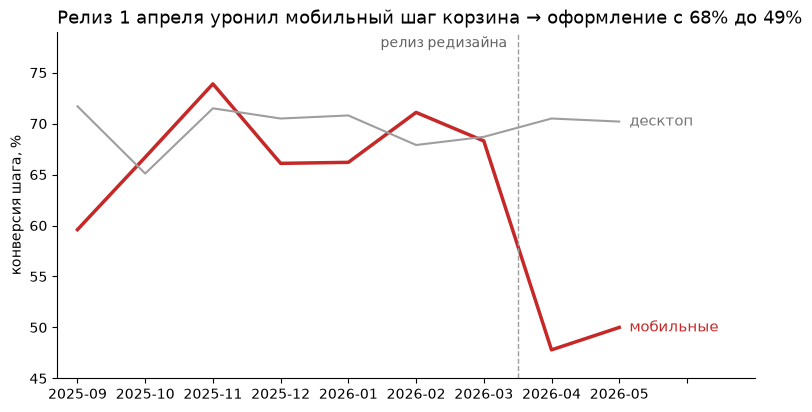

In [9]:
import matplotlib.pyplot as plt

# Мы берем таблицу conv (которая содержит ежедневную конверсию шага cart→checkout для мобильных и десктопов) и оставляем только данные с сентября 2025 года.
trimmed = conv.loc["2025-09":]

# Создаем пустой график размером 9×4.5 дюймов. ax — это объект осей, на который мы будем наносить линии и подписи.
fig, ax = plt.subplots(figsize=(9, 4.5))
trimmed["mobile"].plot(ax=ax, color="#c62828", linewidth=2.5)
trimmed["desktop"].plot(ax=ax, color="#9e9e9e", linewidth=1.5)

# Добавляем вертикальную пунктирную линию на позиции x=6.5 (это 1 апреля 2026, если индекс — это порядковый номер дня с начала отсчета).
ax.axvline(6.5, color="#9e9e9e", linestyle="--", linewidth=1)

# Добавляем текстовую подпись для линий
ax.text(6.35, 77.5, "релиз редизайна", ha="right", color="#616161", fontsize=10)
ax.text(8.15, trimmed["mobile"].iloc[-1], "мобильные", color="#c62828", va="center", fontsize=11)
ax.text(8.15, trimmed["desktop"].iloc[-1], "десктоп", color="#757575", va="center", fontsize=11)

ax.set_title("Релиз 1 апреля уронил мобильный шаг корзина → оформление с 68% до 49%", loc="left", fontsize=13)
ax.set_ylabel("конверсия шага, %")
ax.set_xlabel("")

# Задаем границы осей, чтобы линии не прилипали к краям
ax.set_xlim(-0.3, 10)
ax.set_ylim(45, 79)

# Убираем верхнюю и правую рамки графика
ax.spines[["top", "right"]].set_visible(False)
plt.show()